# Notebook 04 - ViT Training and Captioning

VisionNarrator | Stage 4

---

## 1. Objective

Train an image captioning model end-to-end.

ScratchViT encoder
      ↓
Transformer decoder
      ↓
Caption generation


## 2. Imports

Path
math / Counter
Pandas
PIL
Matplotlib
Torch
Torch Dataset/DataLoader
Torchvision


In [1]:
import math
import platform
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

## 3. Configuration

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
ENCODER_DEPTH = 6
DECODER_DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1
BATCH_SIZE = 32
EPOCHS = 5
LR = 3e-4
MAX_CAPTION_LEN = 25
MIN_WORD_FREQ = 5

LIMIT_TRAIN_BATCHES / LIMIT_VAL_BATCHES cap the number of batches per epoch. Leave them as None for full training on GPU; set them to small numbers (e.g. 300 / 50) for a quick run on CPU.


In [2]:
IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
ENCODER_DEPTH = 6
DECODER_DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1

BATCH_SIZE = 32
EPOCHS = 5
LR = 3e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_FRAC = 0.05

MAX_CAPTION_LEN = 25
MIN_WORD_FREQ = 5

RANDOM_SEED = 42
NUM_WORKERS = 2
LOG_EVERY = 100
LIMIT_TRAIN_BATCHES = None
LIMIT_VAL_BATCHES = None

EFFECTIVE_NUM_WORKERS = 0 if platform.system() == "Windows" else NUM_WORKERS

torch.manual_seed(RANDOM_SEED)

print(f"EMBED_DIM={EMBED_DIM}")
print(f"ENCODER_DEPTH={ENCODER_DEPTH}")
print(f"DECODER_DEPTH={DECODER_DEPTH}")
print(f"BATCH_SIZE={BATCH_SIZE}")
print(f"EPOCHS={EPOCHS}")
print(f"LR={LR}")
print(f"MAX_CAPTION_LEN={MAX_CAPTION_LEN}")
print(f"MIN_WORD_FREQ={MIN_WORD_FREQ}")
print(f"LIMIT_TRAIN_BATCHES={LIMIT_TRAIN_BATCHES}")
print(f"LIMIT_VAL_BATCHES={LIMIT_VAL_BATCHES}")


EMBED_DIM=256
ENCODER_DEPTH=6
DECODER_DEPTH=4
BATCH_SIZE=32
EPOCHS=5
LR=0.0003
MAX_CAPTION_LEN=25
MIN_WORD_FREQ=5
LIMIT_TRAIN_BATCHES=None
LIMIT_VAL_BATCHES=None


## 4. Device Setup

cuda if available
else cpu


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cpu


## 5. Load Flickr30k Splits

train.csv
val.csv
test.csv

Image-level splits saved by Notebook 02.


In [4]:
def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train images: {train_df['image'].nunique():,} | rows: {len(train_df):,}")
print(f"Val images:   {val_df['image'].nunique():,} | rows: {len(val_df):,}")
print(f"Test images:  {test_df['image'].nunique():,} | rows: {len(test_df):,}")


Train images: 22,248 | rows: 111,213
Val images:   4,767 | rows: 23,830
Test images:  4,768 | rows: 23,837


## 6. Create Dataset/DataLoaders

Each item is (image tensor, caption string). Captions stay as strings here and are tokenized batch-wise once the vocabulary exists in section 8.

Augmentation on train only.


In [5]:
train_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

eval_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

class Flickr30kDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        caption = str(row["caption"])
        return image, caption

train_dataset = Flickr30kDataset(train_df, transform=train_transform)
val_dataset = Flickr30kDataset(val_df, transform=eval_transform)
test_dataset = Flickr30kDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

images, captions = next(iter(train_loader))

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")
print(f"images.shape: {tuple(images.shape)}")
print(f"Sample caption: {captions[0]}")


Train batches: 3,476
Val batches:   745
images.shape: (32, 3, 128, 128)
Sample caption: the canter in red and gold sings to his church .


## 7. Load ScratchViT

Same classes as Notebook 03. No pretrained weights exist yet, so the encoder is trained jointly with the decoder.

`forward_features` returns all 65 tokens — (B, 65, 256) — which the decoder cross-attends to as memory.


In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_chans=3, embed_dim=256):
        super().__init__()

        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.num_patches_h = img_size // patch_size
        self.num_patches_w = img_size // patch_size
        self.num_patches = self.num_patches_h * self.num_patches_w

        self.patch_dim = in_chans * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape

        assert H == self.img_size and W == self.img_size, \
            f"Expected image size {(self.img_size, self.img_size)}, got {(H, W)}"

        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, self.patch_dim)

        x = self.proj(patches)

        return x

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

class MLP(nn.Module):
    def __init__(self, embed_dim=256, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ScratchViT(nn.Module):
    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_chans=3,
        embed_dim=256,
        depth=6,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward_features(self, x):
        x = self.patch_embed(x)

        B = x.shape[0]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        return x

    def forward_embedding(self, x):
        x = self.forward_features(x)
        cls_out = x[:, 0]
        return cls_out

    def forward(self, x):
        return self.forward_embedding(x)

encoder = ScratchViT(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    embed_dim=EMBED_DIM,
    depth=ENCODER_DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
)

with torch.no_grad():
    memory = encoder.forward_features(images[:4])

print(f"Encoder input shape: {tuple(images[:4].shape)}")
print(f"Encoder memory shape: {tuple(memory.shape)}")


Encoder input shape: (4, 3, 128, 128)
Encoder memory shape: (4, 65, 256)


## 8. Build Caption Vocabulary/Tokenizer

Special tokens: `<pad>`, `<sos>`, `<eos>`, `<unk>`

lowercase → whitespace split → keep words with frequency ≥ 5

Built from train captions only, so val/test words the model never saw map to `<unk>`. Every caption is encoded as `<sos> w1 w2 ... <eos>` and padded to MAX_CAPTION_LEN.


In [7]:
class Vocabulary:
    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.itos = ["<pad>", "<sos>", "<eos>", "<unk>"]
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

    @staticmethod
    def tokenize(text):
        return text.lower().strip().split()

    def build(self, captions):
        counter = Counter()
        for caption in captions:
            counter.update(self.tokenize(caption))
        for word, freq in sorted(counter.items()):
            if freq >= self.min_freq:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)

    def encode(self, text, max_len):
        tokens = self.tokenize(text)[: max_len - 2]
        ids = [self.stoi["<sos>"]] + [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens] + [self.stoi["<eos>"]]
        ids = ids + [self.stoi["<pad>"]] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            token = self.itos[idx]
            if token == "<eos>":
                break
            if token in ("<pad>", "<sos>"):
                continue
            words.append(token)
        return " ".join(words)

    def __len__(self):
        return len(self.itos)

vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(train_df["caption"].astype(str).tolist())

PAD_IDX = vocab.stoi["<pad>"]
SOS_IDX = vocab.stoi["<sos>"]
EOS_IDX = vocab.stoi["<eos>"]
UNK_IDX = vocab.stoi["<unk>"]

def captions_to_tensor(caption_list, max_len=MAX_CAPTION_LEN):
    return torch.tensor([vocab.encode(caption, max_len) for caption in caption_list], dtype=torch.long)

sample_caption = str(train_df.iloc[0]["caption"])
sample_ids = vocab.encode(sample_caption, MAX_CAPTION_LEN)

print(f"Vocabulary size: {len(vocab):,}")
print(f"Caption: {sample_caption}")
print(f"Encoded: {sample_ids}")
print(f"Decoded: {vocab.decode(sample_ids)}")


Vocabulary size: 6,619
Caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Encoded: [1, 6161, 6602, 2607, 6520, 5037, 2618, 3355, 309, 5890, 2654, 6465, 2658, 3911, 2903, 5888, 6585, 17, 2, 0, 0, 0, 0, 0, 0]
Decoded: two young guys with shaggy hair look at their hands while hanging out in the yard .


## 9. Caption Embedding

nn.Embedding(vocab_size, 256)

Each token id becomes a learnable 256-dim vector. `padding_idx` keeps the `<pad>` row frozen at zero gradient.

(B, 25) → (B, 25, 256)


In [8]:
caption_embed = nn.Embedding(len(vocab), EMBED_DIM, padding_idx=PAD_IDX)

sample_tokens = captions_to_tensor(list(captions[:4]))
embedded = caption_embed(sample_tokens)

print(f"Token ids shape: {tuple(sample_tokens.shape)}")
print(f"Embedded shape: {tuple(embedded.shape)}")


Token ids shape: (4, 25)
Embedded shape: (4, 25, 256)


## 10. Positional Encoding

PE(pos, 2i) = sin(pos / 10000^(2i/d))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

Fixed sinusoidal values, not learned. Each position in the caption gets a unique pattern, added element-wise to the token embeddings.


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim=256, max_len=25):
        super().__init__()

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))
        pe = torch.zeros(1, max_len, embed_dim)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

pos_enc = PositionalEncoding(embed_dim=EMBED_DIM, max_len=MAX_CAPTION_LEN)
encoded = pos_enc(embedded)

print(f"Positional encoding buffer shape: {tuple(pos_enc.pe.shape)}")
print(f"After positional encoding: {tuple(encoded.shape)}")


Positional encoding buffer shape: (1, 25, 256)
After positional encoding: (4, 25, 256)


## 11. Masked Self-Attention

Causal mask: token t may attend to tokens 0..t only.

An upper-triangular boolean mask sets future positions to -inf before softmax, so the decoder cannot copy the next word during training.


In [10]:
class MaskedSelfAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        causal_mask = torch.triu(torch.ones(N, N, device=x.device, dtype=torch.bool), diagonal=1)
        attn = attn.masked_fill(causal_mask, float("-inf"))
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

demo_mask = torch.triu(torch.ones(6, 6, dtype=torch.bool), diagonal=1)
print("Causal mask (True = blocked):")
print(demo_mask.int())

masked_attn_layer = MaskedSelfAttention(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT)
masked_out = masked_attn_layer(encoded)

print(f"Masked self-attention output shape: {tuple(masked_out.shape)}")


Causal mask (True = blocked):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)
Masked self-attention output shape: (4, 25, 256)


## 12. Cross-Attention

Q ← caption tokens
K, V ← 65 image tokens

This is where image information enters the decoder: every caption position queries the encoder memory and pulls in the visual features it needs.

(B, 25, 256) + (B, 65, 256) → (B, 25, 256)


In [11]:
class CrossAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.q = nn.Linear(embed_dim, embed_dim)
        self.kv = nn.Linear(embed_dim, embed_dim * 2)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, memory):
        B, N, D = x.shape
        M = memory.shape[1]

        q = self.q(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        kv = self.kv(memory).reshape(B, M, 2, self.num_heads, self.head_dim)
        kv = kv.permute(2, 0, 3, 1, 4)

        k, v = kv[0], kv[1]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

cross_attn_layer = CrossAttention(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT)
cross_out = cross_attn_layer(masked_out, memory)

print(f"Caption tokens shape: {tuple(masked_out.shape)}")
print(f"Image memory shape: {tuple(memory.shape)}")
print(f"Cross-attention output shape: {tuple(cross_out.shape)}")


Caption tokens shape: (4, 25, 256)
Image memory shape: (4, 65, 256)
Cross-attention output shape: (4, 25, 256)


## 13. Decoder MLP

256 → 1024 → 256

Linear → GELU → Dropout → Linear → Dropout, applied independently to every caption position.


In [12]:
class DecoderMLP(nn.Module):
    def __init__(self, embed_dim=256, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

decoder_mlp = DecoderMLP(embed_dim=EMBED_DIM, mlp_ratio=MLP_RATIO, dropout=DROPOUT)
mlp_out = decoder_mlp(cross_out)

print(f"Decoder MLP hidden dim: {int(EMBED_DIM * MLP_RATIO)}")
print(f"Decoder MLP output shape: {tuple(mlp_out.shape)}")


Decoder MLP hidden dim: 1024
Decoder MLP output shape: (4, 25, 256)


## 14. Transformer Decoder Block

LN
↓
Masked Self-Attention
↓
Residual
↓
LN
↓
Cross-Attention
↓
Residual
↓
LN
↓
MLP
↓
Residual

Pre-norm design with three sublayers instead of the encoder's two.


In [13]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.self_attn = MaskedSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.cross_attn = CrossAttention(embed_dim, num_heads, dropout)

        self.norm3 = nn.LayerNorm(embed_dim)
        self.mlp = DecoderMLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x, memory):
        x = x + self.self_attn(self.norm1(x))
        x = x + self.cross_attn(self.norm2(x), memory)
        x = x + self.mlp(self.norm3(x))
        return x

decoder_block = TransformerDecoderBlock(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, dropout=DROPOUT)
block_out = decoder_block(encoded, memory)

print(f"Block input shape: {tuple(encoded.shape)}")
print(f"Block output shape: {tuple(block_out.shape)}")


Block input shape: (4, 25, 256)
Block output shape: (4, 25, 256)


## 15. Transformer Decoder

Caption Embedding
+
Positional Encoding
+
4 × TransformerDecoderBlock
+
Final LayerNorm
+
Linear(256 → vocab_size)

Output: one distribution over the vocabulary for every caption position — (B, L, vocab_size).


In [14]:
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=256,
        depth=4,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
        max_len=25,
        pad_idx=0,
    ):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(embed_dim, max_len)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerDecoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, tokens, memory):
        x = self.token_embed(tokens)
        x = self.pos_enc(x)
        x = self.drop(x)

        for block in self.blocks:
            x = block(x, memory)

        x = self.norm(x)
        logits = self.head(x)

        return logits

decoder = TransformerDecoder(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    depth=DECODER_DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    max_len=MAX_CAPTION_LEN,
    pad_idx=PAD_IDX,
)

with torch.no_grad():
    demo_logits = decoder(sample_tokens, memory)

print(f"Decoder logits shape: {tuple(demo_logits.shape)}")


Decoder logits shape: (4, 25, 6619)


## 16. Image Captioning Model

images → encoder → memory (B, 65, 256)
tokens → decoder(tokens, memory) → logits (B, L, vocab_size)

Teacher forcing: the decoder input is the caption shifted right (`<sos> w1 ... w_{n-1}`) and the target is the caption shifted left (`w1 ... w_n <eos>`).


In [15]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, tokens):
        memory = self.encoder.forward_features(images)
        logits = self.decoder(tokens, memory)
        return logits

caption_model = ImageCaptioningModel(encoder, decoder).to(device)

total_params = sum(p.numel() for p in caption_model.parameters())
encoder_params = sum(p.numel() for p in caption_model.encoder.parameters())
decoder_params = sum(p.numel() for p in caption_model.decoder.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Encoder parameters: {encoder_params:,}")
print(f"Decoder parameters: {decoder_params:,}")


Total parameters: 12,562,651
Encoder parameters: 4,952,832
Decoder parameters: 7,609,819


## 17. Forward Pass Test

(B, 3, 128, 128) + (B, 24)
       ↓
(B, 24, vocab_size)


In [16]:
images, captions = next(iter(train_loader))
tokens = captions_to_tensor(list(captions))

images = images.to(device)
tokens = tokens.to(device)

tokens_in = tokens[:, :-1]
targets = tokens[:, 1:]

caption_model.eval()
with torch.no_grad():
    logits = caption_model(images, tokens_in)

print(f"Images shape: {tuple(images.shape)}")
print(f"Tokens in shape: {tuple(tokens_in.shape)}")
print(f"Targets shape: {tuple(targets.shape)}")
print(f"Logits shape: {tuple(logits.shape)}")

assert logits.shape == (images.size(0), MAX_CAPTION_LEN - 1, len(vocab))


Images shape: (32, 3, 128, 128)
Tokens in shape: (32, 24)
Targets shape: (32, 24)
Logits shape: (32, 24, 6619)


## 18. Loss Function

Cross-entropy over the vocabulary at every position, with `<pad>` positions ignored.

An untrained model should score close to the random-guess baseline ln(vocab_size).


In [17]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

demo_loss = criterion(logits.reshape(-1, len(vocab)), targets.reshape(-1))

print(f"Untrained model loss: {demo_loss.item():.4f}")
print(f"Random-guess baseline: {math.log(len(vocab)):.4f}")


Untrained model loss: 8.9285
Random-guess baseline: 8.7977


## 19. Optimizer

AdamW

lr = 3e-4
weight_decay = 0.01


In [18]:
optimizer = torch.optim.AdamW(caption_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"Optimizer: {type(optimizer).__name__}")
print(f"LR: {optimizer.param_groups[0]['lr']}")
print(f"Weight decay: {optimizer.param_groups[0]['weight_decay']}")


Optimizer: AdamW
LR: 0.0003
Weight decay: 0.01


## 20. Learning Rate Scheduler

Linear warmup (first 5% of steps)
      ↓
Cosine decay to 0

Stepped once per batch, not per epoch.


In [19]:
steps_per_epoch = len(train_loader) if LIMIT_TRAIN_BATCHES is None else min(LIMIT_TRAIN_BATCHES, len(train_loader))
total_steps = EPOCHS * steps_per_epoch
warmup_steps = max(1, int(WARMUP_FRAC * total_steps))

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")


Steps per epoch: 3476
Total steps: 17380
Warmup steps: 869


## 21. Training Loop

For every batch: encode captions → shift for teacher forcing → forward → cross-entropy → backward → clip gradients → step optimizer and scheduler.


In [20]:
def train_one_epoch(epoch):
    caption_model.train()
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(train_loader, start=1):
        if LIMIT_TRAIN_BATCHES is not None and step > LIMIT_TRAIN_BATCHES:
            break

        batch_images = batch_images.to(device)
        batch_tokens = captions_to_tensor(list(batch_captions)).to(device)

        tokens_in = batch_tokens[:, :-1]
        targets = batch_tokens[:, 1:]

        optimizer.zero_grad()
        batch_logits = caption_model(batch_images, tokens_in)
        loss = criterion(batch_logits.reshape(-1, len(vocab)), targets.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(caption_model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        batches += 1

        if step % LOG_EVERY == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"epoch {epoch} | step {step}/{steps_per_epoch} | loss {loss.item():.4f} | lr {current_lr:.2e}")

    return total_loss / max(batches, 1)


## 22. Validation Loop

Same loss computation, no gradients, no augmentation (val loader already uses eval_transform).


In [21]:
@torch.no_grad()
def evaluate(loader, limit_batches=None):
    caption_model.eval()
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(loader, start=1):
        if limit_batches is not None and step > limit_batches:
            break

        batch_images = batch_images.to(device)
        batch_tokens = captions_to_tensor(list(batch_captions)).to(device)

        tokens_in = batch_tokens[:, :-1]
        targets = batch_tokens[:, 1:]

        batch_logits = caption_model(batch_images, tokens_in)
        loss = criterion(batch_logits.reshape(-1, len(vocab)), targets.reshape(-1))

        total_loss += loss.item()
        batches += 1

    return total_loss / max(batches, 1)


## 23. Checkpointing

After every epoch:

last.pt — always overwritten
best.pt — only when val loss improves

This cell runs the full training.


In [22]:
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

def save_checkpoint(path, epoch, val_loss):
    torch.save(
        {
            "epoch": epoch,
            "val_loss": val_loss,
            "model_state": caption_model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "vocab_itos": vocab.itos,
        },
        path,
    )

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(epoch)
    val_loss = evaluate(val_loader, LIMIT_VAL_BATCHES)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(CHECKPOINT_DIR / "last.pt", epoch, val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(CHECKPOINT_DIR / "best.pt", epoch, val_loss)
        marker = " | new best"

    print(f"epoch {epoch}/{EPOCHS} | train {train_loss:.4f} | val {val_loss:.4f}{marker}")


epoch 1 | step 100/3476 | loss 7.5361 | lr 3.49e-05
epoch 1 | step 200/3476 | loss 6.1964 | lr 6.94e-05
epoch 1 | step 300/3476 | loss 5.4082 | lr 1.04e-04
epoch 1 | step 400/3476 | loss 4.7930 | lr 1.38e-04
epoch 1 | step 500/3476 | loss 4.8834 | lr 1.73e-04
epoch 1 | step 600/3476 | loss 4.5480 | lr 2.07e-04
epoch 1 | step 700/3476 | loss 4.4541 | lr 2.42e-04
epoch 1 | step 800/3476 | loss 4.2906 | lr 2.77e-04
epoch 1 | step 900/3476 | loss 4.3060 | lr 3.00e-04
epoch 1 | step 1000/3476 | loss 4.2777 | lr 3.00e-04
epoch 1 | step 1100/3476 | loss 3.9112 | lr 3.00e-04
epoch 1 | step 1200/3476 | loss 3.8596 | lr 3.00e-04
epoch 1 | step 1300/3476 | loss 4.1121 | lr 2.99e-04
epoch 1 | step 1400/3476 | loss 4.0019 | lr 2.99e-04
epoch 1 | step 1500/3476 | loss 3.6076 | lr 2.99e-04
epoch 1 | step 1600/3476 | loss 3.8010 | lr 2.99e-04
epoch 1 | step 1700/3476 | loss 4.1345 | lr 2.98e-04
epoch 1 | step 1800/3476 | loss 3.6944 | lr 2.98e-04
epoch 1 | step 1900/3476 | loss 3.5064 | lr 2.97e-04
ep

## 24. Training Curves

Train loss
vs
Val loss


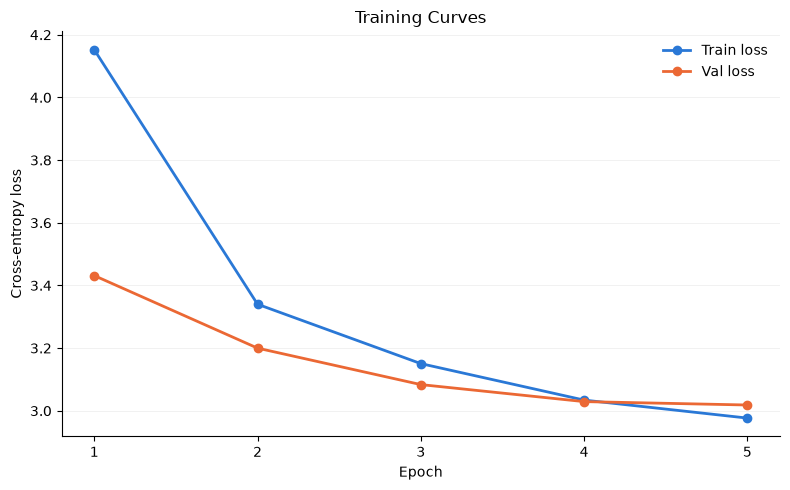

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax.plot(epochs_range, history["train_loss"], color="#2a78d6", linewidth=2, marker="o", markersize=6, label="Train loss")
ax.plot(epochs_range, history["val_loss"], color="#eb6834", linewidth=2, marker="o", markersize=6, label="Val loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training Curves")
ax.set_xticks(list(epochs_range))
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.5)

plt.tight_layout()
plt.show()

## 25. Generate Sample Captions

Greedy decoding: start from `<sos>`, feed the sequence back in, take argmax of the last position, stop at `<eos>` or MAX_CAPTION_LEN.

Uses the best checkpoint.


Loaded best checkpoint: epoch 5 | val loss 3.0184


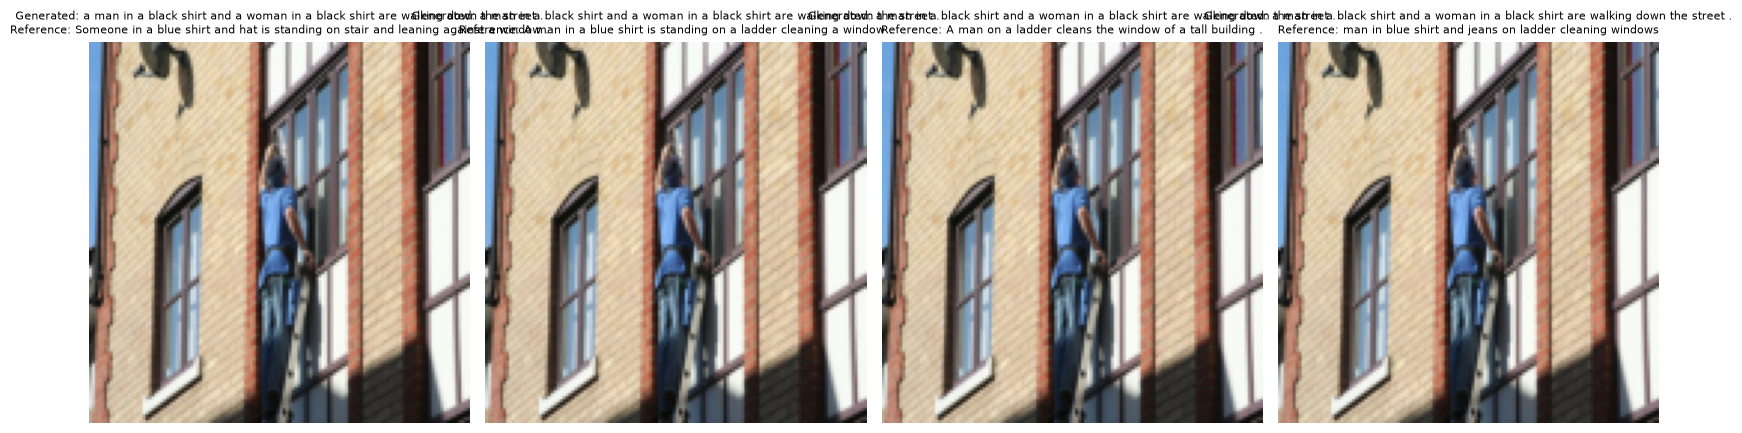

In [24]:
best_ckpt = torch.load(CHECKPOINT_DIR / "best.pt", map_location=device)
caption_model.load_state_dict(best_ckpt["model_state"])

print(f"Loaded best checkpoint: epoch {best_ckpt['epoch']} | val loss {best_ckpt['val_loss']:.4f}")

@torch.no_grad()
def generate_caption(image_tensor, max_len=MAX_CAPTION_LEN):
    caption_model.eval()
    image_memory = caption_model.encoder.forward_features(image_tensor.unsqueeze(0).to(device))
    generated = torch.full((1, 1), SOS_IDX, dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        step_logits = caption_model.decoder(generated, image_memory)
        next_token = step_logits[:, -1].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == EOS_IDX:
            break

    return vocab.decode(generated[0].tolist())

def denormalize_image(image_tensor: torch.Tensor) -> torch.Tensor:
    image = image_tensor.detach().cpu().clone()
    image = image * 0.5 + 0.5
    return image.clamp(0, 1)

val_images, val_captions = next(iter(val_loader))

num_examples = 4
fig, axes = plt.subplots(1, num_examples, figsize=(16, 5))

for idx in range(num_examples):
    generated_caption = generate_caption(val_images[idx])
    axes[idx].imshow(denormalize_image(val_images[idx]).permute(1, 2, 0))
    axes[idx].set_title(f"Generated: {generated_caption}\nReference: {val_captions[idx]}", fontsize=8)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 26. Save Best Model

Weights + vocabulary + config in one file, so inference needs nothing else.


In [25]:
MODEL_DIR = BASE_DIR / "src" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_DIR / "vit_captioner.pt"

torch.save(
    {
        "model_state": caption_model.state_dict(),
        "vocab_itos": vocab.itos,
        "best_val_loss": best_val_loss,
        "config": {
            "img_size": IMG_SIZE,
            "patch_size": PATCH_SIZE,
            "embed_dim": EMBED_DIM,
            "encoder_depth": ENCODER_DEPTH,
            "decoder_depth": DECODER_DEPTH,
            "num_heads": NUM_HEADS,
            "mlp_ratio": MLP_RATIO,
            "dropout": DROPOUT,
            "max_caption_len": MAX_CAPTION_LEN,
            "min_word_freq": MIN_WORD_FREQ,
        },
    },
    FINAL_MODEL_PATH,
)

print(f"Saved: {FINAL_MODEL_PATH}")
print(f"Best val loss: {best_val_loss:.4f}")


Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\models\vit_captioner.pt
Best val loss: 3.0184
